In [1]:
import pandas as pd

# 读取Excel文件
df = pd.read_excel('ab实验数据_for优惠券 (1).xlsx')

# 查看前5行
df.head()

,uid,组别,是否发券,当天是否下单,7天是否下单,发券前30天单量,发券前90天单量,发券前180天单量,发券前30天单均价格,发券前90天单均价格,发券前180天单均价格,最近一次下单时间（距发券）,过去30天浏览但未下单次数,性别,年龄,城市等级,系统设备,发券前30天单量/90天单量,发券前30天单量/180天单量,价格趋势
0,5737808,control,0,0,0,1,5,2,248,322,354,23,10,男,18-24岁,新一线,安卓,0.600000,3.000000,0
1,3151204,control,0,0,0,3,7,30,414,621,869,8,9,男,18-24岁,三线,安卓,1.285714,0.600000,-1
2,6911072,control,0,0,0,8,17,9,385,577,750,20,17,女,36-40岁,二线,安卓,1.411765,5.333333,-1
3,7489548,control,0,0,0,0,0,2,0,58,58,90,10,男,18-24岁,二线,安卓,0.000000,0.000000,-1
4,8213674,control,0,0,0,4,11,3,160,192,230,10,9,男,18-24岁,一线,安卓,1.090909,8.000000,0


In [3]:
# 数据维度
print('数据集形状：', df.shape)

# 查看列名
print(df.columns.tolist())

# 查看数据类型
df.info()

# 查看前5行
df.head()

数据集形状： (8108, 20)
['uid', '组别', '是否发券', '当天是否下单', '7天是否下单', '发券前30天单量', '发券前90天单量', '发券前180天单量', '发券前30天单均价格', '发券前90天单均价格', '发券前180天单均价格', '最近一次下单时间（距发券）', '过去30天浏览但未下单次数', '性别', '年龄', '城市等级', '系统设备', '发券前30天单量/90天单量', '发券前30天单量/180天单量', '价格趋势']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   uid              8108 non-null   int64  
 1   组别               8108 non-null   object 
 2   是否发券             8108 non-null   int64  
 3   当天是否下单           8108 non-null   int64  
 4   7天是否下单           8108 non-null   int64  
 5   发券前30天单量         8108 non-null   int64  
 6   发券前90天单量         8108 non-null   int64  
 7   发券前180天单量        8108 non-null   int64  
 8   发券前30天单均价格       8108 non-null   int64  
 9   发券前90天单均价格       8108 non-null   int64  
 10  发券前180天单均价格      8108 non-null   int64  
 11  最近一次下单时间（距发券）    8108 non-null   int64  
 1

,uid,组别,是否发券,当天是否下单,7天是否下单,发券前30天单量,发券前90天单量,发券前180天单量,发券前30天单均价格,发券前90天单均价格,发券前180天单均价格,最近一次下单时间（距发券）,过去30天浏览但未下单次数,性别,年龄,城市等级,系统设备,发券前30天单量/90天单量,发券前30天单量/180天单量,价格趋势
0,5737808,control,0,0,0,1,5,2,248,322,354,23,10,男,18-24岁,新一线,安卓,0.600000,3.000000,0
1,3151204,control,0,0,0,3,7,30,414,621,869,8,9,男,18-24岁,三线,安卓,1.285714,0.600000,-1
2,6911072,control,0,0,0,8,17,9,385,577,750,20,17,女,36-40岁,二线,安卓,1.411765,5.333333,-1
3,7489548,control,0,0,0,0,0,2,0,58,58,90,10,男,18-24岁,二线,安卓,0.000000,0.000000,-1
4,8213674,control,0,0,0,4,11,3,160,192,230,10,9,男,18-24岁,一线,安卓,1.090909,8.000000,0


In [5]:
# 每列缺失值数量
df.isnull().sum()

# 缺失率
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

uid                0.0
组别                 0.0
发券前30天单量/180天单量    0.0
发券前30天单量/90天单量     0.0
系统设备               0.0
城市等级               0.0
年龄                 0.0
性别                 0.0
过去30天浏览但未下单次数      0.0
最近一次下单时间（距发券）      0.0
发券前180天单均价格        0.0
发券前90天单均价格         0.0
发券前30天单均价格         0.0
发券前180天单量          0.0
发券前90天单量           0.0
发券前30天单量           0.0
7天是否下单             0.0
当天是否下单             0.0
是否发券               0.0
价格趋势               0.0
dtype: float64

In [9]:
df['组别'].value_counts()

组别
control      4054
treatment    4054
Name: count, dtype: int64

In [11]:
from scipy.stats import chisquare

obs = df['组别'].value_counts().values

expected = [len(df)/2, len(df)/2]

chi2, p = chisquare(obs, expected)

print("Chi-square =", chi2)
print("p-value =", p)

Chi-square = 0.0
p-value = 1.0


In [13]:
if p > 0.05:
    print("随机分组正常，无SRM问题")
else:
    print("存在SRM问题，需要排查实验流量")

随机分组正常，无SRM问题


In [15]:
from scipy.stats import ttest_ind

num_cols = [
    '发券前30天单量',
    '发券前90天单量',
    '发券前180天单量',
    '发券前30天单均价格',
    '最近一次下单时间（距发券）',
    '过去30天浏览但未下单次数'
]

for col in num_cols:

    control = df[df['组别']=='control'][col]
    treatment = df[df['组别']=='treatment'][col]

    stat,p = ttest_ind(
        control,
        treatment,
        equal_var=False
    )

    print(f'{col}: p={p:.4f}')

发券前30天单量: p=1.0000
发券前90天单量: p=1.0000
发券前180天单量: p=0.2182
发券前30天单均价格: p=0.3464
最近一次下单时间（距发券）: p=0.8348
过去30天浏览但未下单次数: p=0.8054


In [19]:
from scipy.stats import chi2_contingency

cat_cols = [
    '性别',
    '年龄',
    '城市等级',
    '系统设备'
]

for col in cat_cols:

    table = pd.crosstab(
        df[col],
        df['组别']
    )

    chi2,p,_,_ = chi2_contingency(table)

    print(f'{col}: p={p:.4f}')

性别: p=0.4627
年龄: p=0.4936
城市等级: p=0.1725
系统设备: p=0.4243


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
import matplotlib.pyplot as plt

# Windows
plt.rcParams['font.sans-serif'] = ['SimHei']

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

In [35]:
result = df.groupby('组别')[['当天是否下单', '7天是否下单']].mean()

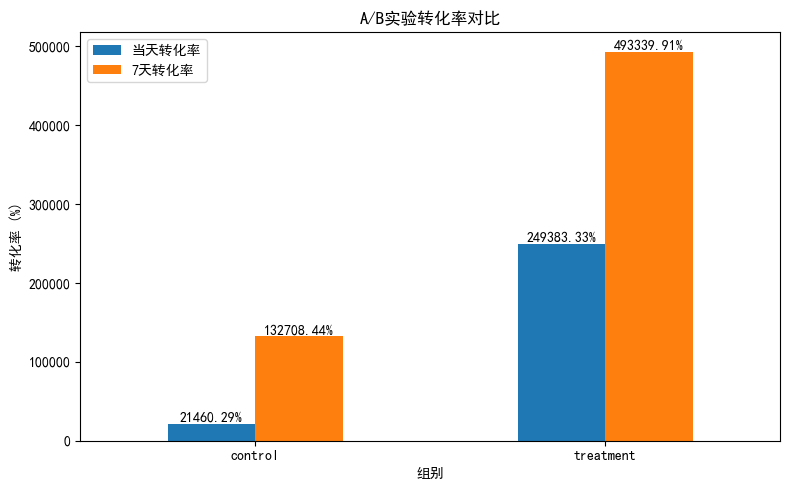

In [45]:
result = result * 100

# 画图
ax = result.plot(
    kind='bar',
    figsize=(8,5),
    rot=0
)

plt.title('A/B实验转化率对比')
plt.ylabel('转化率 (%)')
plt.xlabel('组别')

# 显示数值
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.legend(['当天转化率','7天转化率'])
plt.tight_layout()
plt.show()

In [23]:
control = df[df['组别'] == 'control']
treatment = df[df['组别'] == 'treatment']

for col in ['当天是否下单', '7天是否下单']:
    cvr_c = control[col].mean()
    cvr_t = treatment[col].mean()
    print(col)
    print('绝对提升:', cvr_t - cvr_c)
    print('相对提升:', (cvr_t - cvr_c) / cvr_c)

当天是否下单
绝对提升: 0.22792303897385296
相对提升: 10.620689655172413
7天是否下单
绝对提升: 0.3606314750863345
相对提升: 2.7174721189591073


In [25]:
control = df[df['组别'] == 'control']
treatment = df[df['组别'] == 'treatment']

for col in ['当天是否下单', '7天是否下单']:
    cvr_c = control[col].mean()
    cvr_t = treatment[col].mean()
    print(col)
    print('绝对提升:', cvr_t - cvr_c)
    print('相对提升:', (cvr_t - cvr_c) / cvr_c)

当天是否下单
绝对提升: 0.22792303897385296
相对提升: 10.620689655172413
7天是否下单
绝对提升: 0.3606314750863345
相对提升: 2.7174721189591073


In [27]:
for col in ['性别', '年龄', '城市等级', '系统设备']:
    print(df.groupby(['组别', col])['7天是否下单'].mean())

组别         性别
control    女     0.135207
           男     0.130535
treatment  女     0.497396
           男     0.489691
Name: 7天是否下单, dtype: float64
组别         年龄     
control    18-24岁     0.148718
           18岁以下      0.080000
           25-30岁     0.121739
           31-35岁     0.119360
           36-40岁     0.131796
           41-45岁     0.137353
           46-50岁     0.129944
           50-55岁     0.157609
           56-60岁     0.155556
           60岁-65岁    0.153846
treatment  18-24岁     0.469751
           18岁以下      0.336957
           25-30岁     0.526316
           31-35岁     0.524017
           36-40岁     0.503077
           41-45岁     0.451839
           46-50岁     0.500000
           50-55岁     0.487047
           56-60岁     0.472222
           60岁-65岁    0.603448
Name: 7天是否下单, dtype: float64
组别         城市等级 
control    一线       0.132231
           三线       0.129686
           二线       0.140113
           五线及以下    0.150997
           四线       0.125000
           新一线      0.1

In [29]:
df['历史购买分层'] = pd.qcut(
    df['发券前30天单量'],
    q=4,
    labels=['低频', '中低频', '中高频', '高频']
)

df.groupby(['组别', '历史购买分层'])['7天是否下单'].mean()

C:\Users\cjmwo\AppData\Local\Temp\ipykernel_41712\2259847181.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['组别', '历史购买分层'])['7天是否下单'].mean()


组别         历史购买分层
control    低频        0.082090
           中低频       0.156315
           中高频       0.154657
           高频        0.183315
treatment  低频        0.628731
           中低频       0.395445
           中高频       0.386643
           高频        0.424808
Name: 7天是否下单, dtype: float64

In [49]:
result = df.groupby(
    ['历史购买分层','组别']
)['7天是否下单'].mean().unstack()

result = result * 100
result

C:\Users\cjmwo\AppData\Local\Temp\ipykernel_41712\1824115016.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(


组别,control,treatment
历史购买分层,,
低频,8.208955,62.873134
中低频,15.631470,39.544513
中高频,15.465729,38.664323
高频,18.331504,42.480790


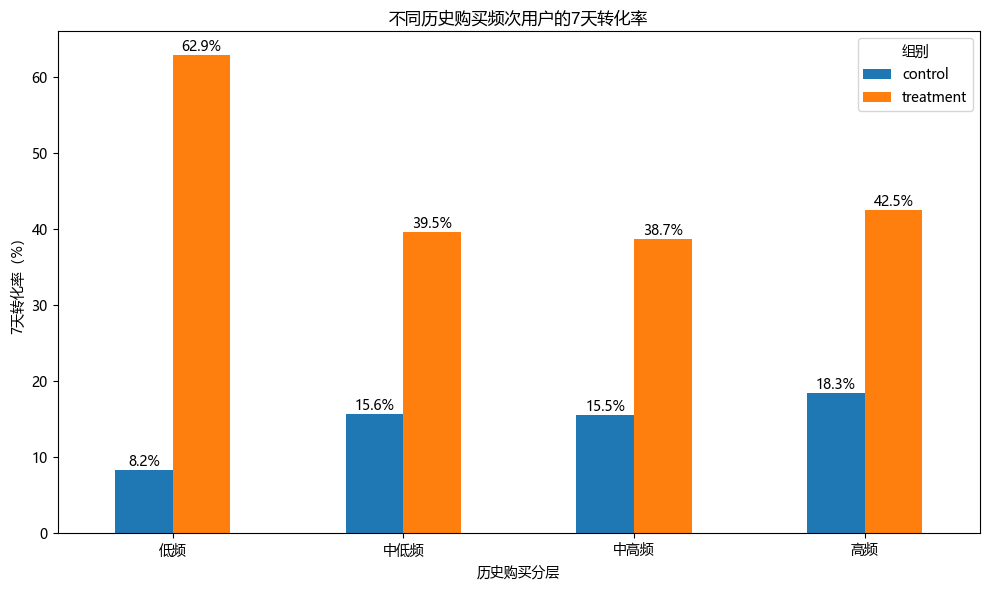

In [51]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

ax = result.plot(
    kind='bar',
    figsize=(10,6),
    rot=0
)

plt.title('不同历史购买频次用户的7天转化率')
plt.xlabel('历史购买分层')
plt.ylabel('7天转化率（%）')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.legend(title='组别')
plt.tight_layout()
plt.show()

C:\Users\cjmwo\AppData\Local\Temp\ipykernel_41712\3649814795.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h = df.groupby(


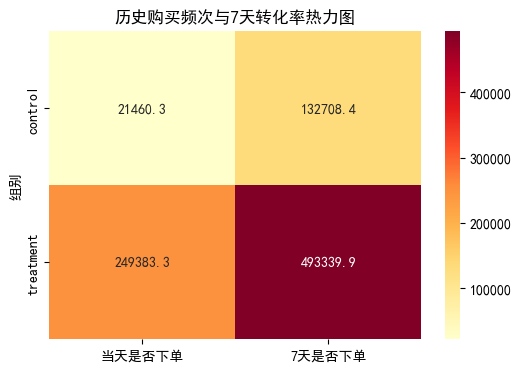

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

h = df.groupby(
    ['历史购买分层','组别']
)['7天是否下单'].mean().unstack()*100

plt.figure(figsize=(6,4))

sns.heatmap(
    result,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('历史购买频次与7天转化率热力图')
plt.show()

In [31]:
df['浏览分层'] = pd.qcut(
    df['过去30天浏览但未下单次数'],
    q=4,
    labels=['低浏览', '中低浏览', '中高浏览', '高浏览']
)

df.groupby(['组别', '浏览分层'])['7天是否下单'].mean()

C:\Users\cjmwo\AppData\Local\Temp\ipykernel_41712\2444481068.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['组别', '浏览分层'])['7天是否下单'].mean()


组别         浏览分层
control    低浏览     0.134565
           中低浏览    0.160297
           中高浏览    0.135462
           高浏览     0.094363
treatment  低浏览     0.290861
           中低浏览    0.298539
           中高浏览    0.545032
           高浏览     0.903519
Name: 7天是否下单, dtype: float64

In [53]:
result = df.groupby(
    ['浏览分层','组别']
)['7天是否下单'].mean().unstack() * 100

result

C:\Users\cjmwo\AppData\Local\Temp\ipykernel_41712\2773116702.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(


组别,control,treatment
浏览分层,,
低浏览,13.456464,29.086116
中低浏览,16.029724,29.853862
中高浏览,13.546160,54.503250
高浏览,9.436275,90.351873


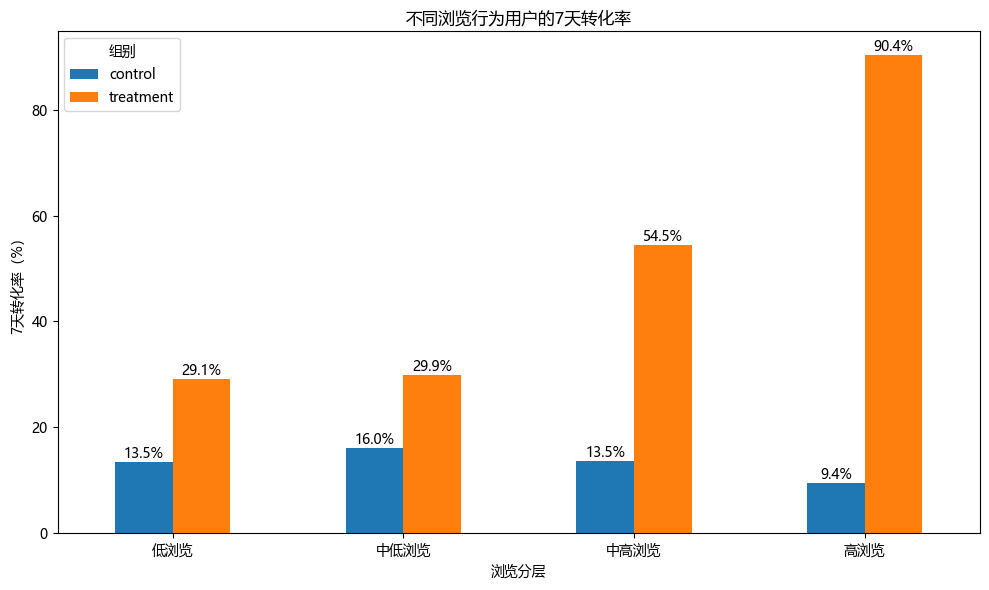

In [55]:


ax = result.plot(
    kind='bar',
    figsize=(10,6),
    rot=0
)

plt.title('不同浏览行为用户的7天转化率')
plt.xlabel('浏览分层')
plt.ylabel('7天转化率（%）')

# 显示数值标签
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.legend(title='组别')
plt.tight_layout()
plt.show()

In [33]:
df.groupby(['组别', '价格趋势'])['7天是否下单'].mean()

组别         价格趋势
control    -1      0.086547
            0      0.150514
            1      0.165644
treatment  -1      0.790777
            0      0.372757
            1      0.368421
Name: 7天是否下单, dtype: float64

In [57]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df['组别']=='control']
treatment = df[df['组别']=='treatment']

count = [
    treatment['7天是否下单'].sum(),
    control['7天是否下单'].sum()
]

nobs = [
    len(treatment),
    len(control)
]

stat,p = proportions_ztest(
    count,
    nobs
)

print("Z-stat =",stat)
print("p-value =",p)

Z-stat = 35.0131219294664
p-value = 1.4206620345350008e-268


In [63]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from econml.dml import CausalForestDML



# 目标变量
y = df['7天是否下单'].astype(int)

# 处理变量：是否发券，必须是0/1
T = df['是否发券'].astype(int)

# 特征列
num_cols = [
    '发券前30天单量',
    '发券前90天单量',
    '发券前180天单量',
    '发券前30天单均价格',
    '发券前90天单均价格',
    '发券前180天单均价格',
    '最近一次下单时间（距发券）',
    '过去30天浏览但未下单次数',
    '发券前30天单量/90天单量',
    '发券前30天单量/180天单量'
]

cat_cols = [
    '性别',
    '年龄',
    '城市等级',
    '系统设备',
    '价格趋势'
]

X = df[num_cols + cat_cols]

# 预处理：数值标准化，类别One-Hot
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X_processed = preprocess.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    X_processed,
    y,
    T,
    test_size=0.2,
    random_state=42,
    stratify=T
)

from sklearn.ensemble import RandomForestClassifier
from econml.dml import CausalForestDML

model = CausalForestDML(
    model_y=RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=50,
        random_state=42
    ),
    model_t=RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=50,
        random_state=42
    ),
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=8,
    random_state=42
)

model.fit(
    Y=y_train,
    T=T_train,
    X=X_train
)

# 预测uplift
uplift_train = model.effect(X_train)
uplift_test = model.effect(X_test)

print("训练集平均Uplift:", uplift_train.mean())
print("测试集平均Uplift:", uplift_test.mean())

训练集平均Uplift: 0.35627528976975914
测试集平均Uplift: 0.3457705955523374


In [75]:
import numpy as np
import pandas as pd

uplift_test_1d = np.ravel(uplift_test)
uplift_train_1d = np.ravel(uplift_train)

In [77]:
test_result = pd.DataFrame({
    'y_test': np.ravel(y_test),
    'T_test': np.ravel(T_test),
    'uplift_score': uplift_test_1d
})

train_result = pd.DataFrame({
    'y_train': np.ravel(y_train),
    'T_train': np.ravel(T_train),
    'uplift_score': uplift_train_1d
})

In [79]:
top_test_uplift = test_result.sort_values(
    by='uplift_score',
    ascending=False
)

top_train_uplift = train_result.sort_values(
    by='uplift_score',
    ascending=False
)

print("测试集前10高Uplift Score：")
print(top_test_uplift.head(10))

print("训练集前10高Uplift Score：")
print(top_train_uplift.head(10))

测试集前10高Uplift Score：
      y_test  T_test  uplift_score
1614       0       0      0.953621
1104       1       1      0.953276
614        0       0      0.953262
1481       1       1      0.953125
1346       0       0      0.952932
1160       0       0      0.952712
710        1       1      0.952353
190        1       1      0.952308
897        1       1      0.952205
211        1       1      0.952105
训练集前10高Uplift Score：
      y_train  T_train  uplift_score
4559        0        0      0.954178
6351        1        1      0.954125
40          1        1      0.954076
3715        0        0      0.954033
5173        0        0      0.953680
5420        1        1      0.953621
6009        0        0      0.953621
4901        1        1      0.953549
3251        1        1      0.953496
2602        1        1      0.953425


In [65]:
print("平均Uplift：", uplift_test.mean())

print("最大Uplift：", uplift_test.max())

print("最小Uplift：", uplift_test.min())

平均Uplift： 0.3457705955523374
最大Uplift： 0.9536205647487977
最小Uplift： -0.20285212453759466


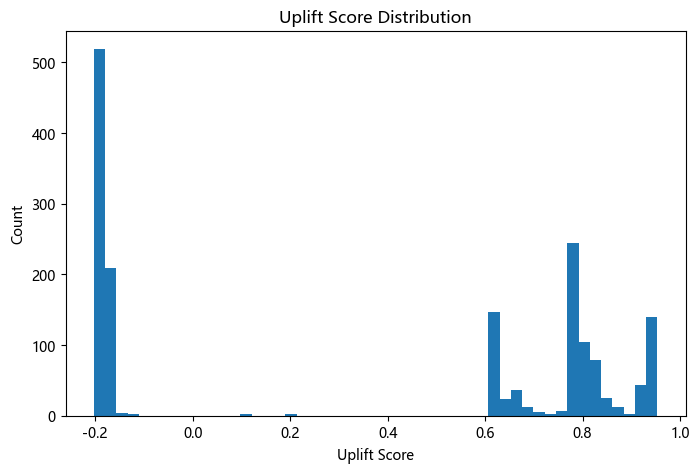

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    uplift_test,
    bins=50
)

plt.xlabel("Uplift Score")
plt.ylabel("Count")

plt.title("Uplift Score Distribution")

plt.show()


训练集数据检查
   treatment  y_true    uplift
0          0       0  0.952652
1          0       0  0.663868
2          0       0  0.627412
3          1       1  0.825971
4          0       0  0.780238
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   treatment  6486 non-null   int32  
 1   y_true     6486 non-null   int32  
 2   uplift     6486 non-null   float64
dtypes: float64(1), int32(2)
memory usage: 101.5 KB
None
treatment    0
y_true       0
uplift       0
dtype: int64
treatment
0    3243
1    3243
Name: count, dtype: int64
y_true
0    4439
1    2047
Name: count, dtype: int64

测试集数据检查
   treatment  y_true    uplift
0          1       0  0.833967
1          0       0 -0.173666
2          0       0  0.790654
3          1       1  0.918769
4          0       0  0.616213
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data c

<Figure size 800x600 with 0 Axes>

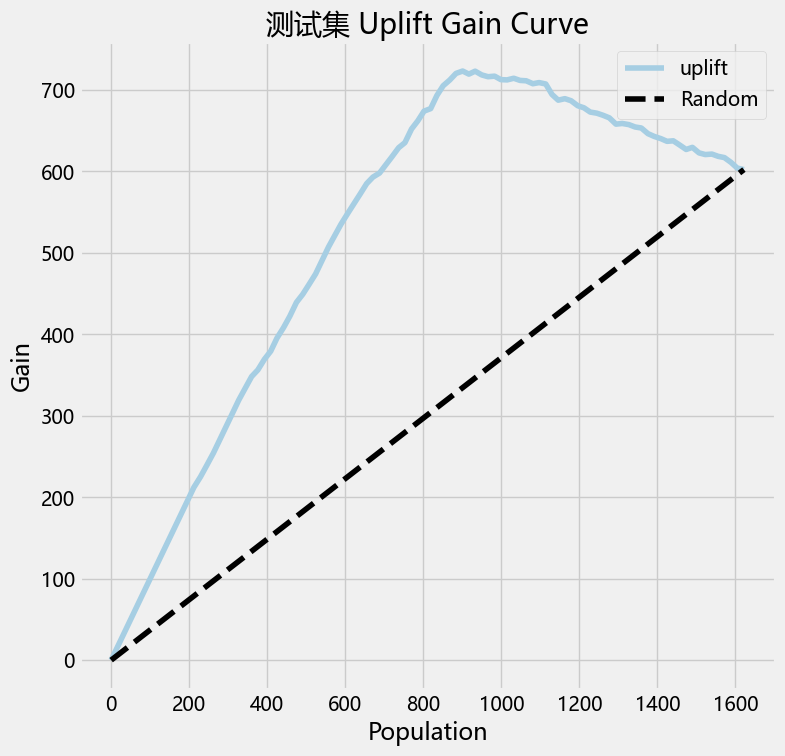

<Figure size 800x600 with 0 Axes>

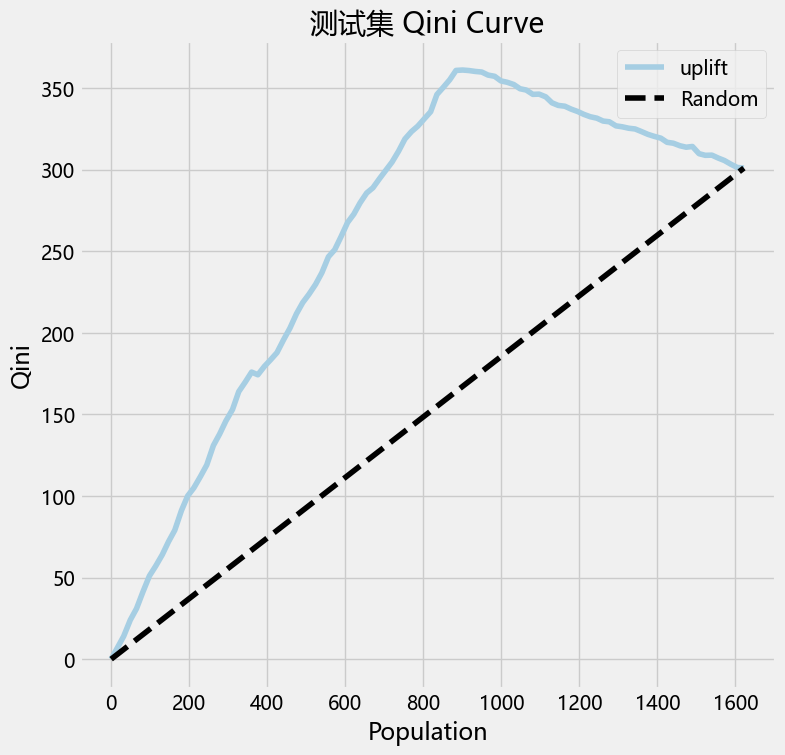


========== Uplift 分层结果 ==========


The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,uplift_group,用户数,平均Uplift,实际转化率,发券比例
0,最低20%,325,-0.190584,0.076923,0.510769
1,较低20%,324,-0.180350,0.095679,0.493827
2,中等20%,324,0.419606,0.376543,0.521605
3,较高20%,324,0.788256,0.459877,0.462963
4,最高20%,325,0.891895,0.504615,0.510769



========== 各Uplift分层真实Lift ==========


The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Control转化率,Treatment转化率,实际Lift
uplift_group,,,
最低20%,0.157233,0.000000,-0.157233
较低20%,0.189024,0.000000,-0.189024
中等20%,0.148387,0.585799,0.437412
较高20%,0.086207,0.893333,0.807126
最高20%,0.006289,0.981928,0.975638


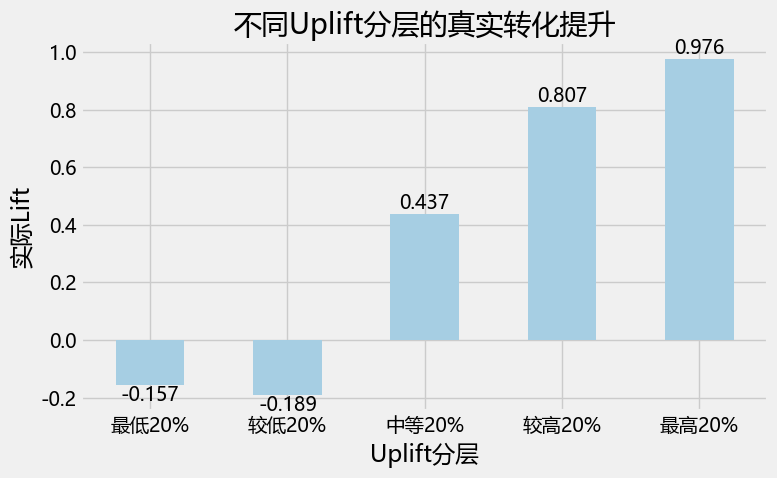

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalml.metrics import auuc_score, plot_gain, plot_qini


# ========== 1. 工具函数：转成一维 ==========
def to_1d(x):
    return np.asarray(x).ravel()


# ========== 2. 构造 causalml 需要的数据 ==========
train_df = pd.DataFrame({
    'treatment': to_1d(T_train),
    'y_true': to_1d(y_train),
    'uplift': to_1d(uplift_train)
})

test_df = pd.DataFrame({
    'treatment': to_1d(T_test),
    'y_true': to_1d(y_test),
    'uplift': to_1d(uplift_test)
})


# ========== 3. 数据检查 ==========
for name, data in [('训练集', train_df), ('测试集', test_df)]:
    print(f'\n{name}数据检查')
    print(data.head())
    print(data.info())
    print(data.isnull().sum())
    print(data['treatment'].value_counts())
    print(data['y_true'].value_counts())


# ========== 4. 计算 AUUC ==========
auuc_train_result = auuc_score(
    df=train_df,
    outcome_col='y_true',
    treatment_col='treatment',
    uplift_col='uplift',
    normalize=True
)

auuc_test_result = auuc_score(
    df=test_df,
    outcome_col='y_true',
    treatment_col='treatment',
    uplift_col='uplift',
    normalize=True
)

# 兼容 Series / float 返回
auuc_train = auuc_train_result.iloc[0] if hasattr(auuc_train_result, 'iloc') else auuc_train_result
auuc_test = auuc_test_result.iloc[0] if hasattr(auuc_test_result, 'iloc') else auuc_test_result

print('\n========== AUUC 结果 ==========')
print(f'训练集 AUUC: {float(auuc_train):.4f}')
print(f'测试集 AUUC: {float(auuc_test):.4f}')


# ========== 5. 画 Gain Curve ==========
plt.figure(figsize=(8, 6))
plot_gain(
    test_df,
    outcome_col='y_true',
    treatment_col='treatment'
)
plt.title('测试集 Uplift Gain Curve')
plt.show()


# ========== 6. 画 Qini Curve ==========
plt.figure(figsize=(8, 6))
plot_qini(
    test_df,
    outcome_col='y_true',
    treatment_col='treatment'
)
plt.title('测试集 Qini Curve')
plt.show()


# ========== 7. Uplift 分层验证 ==========
test_df['uplift_group'] = pd.qcut(
    test_df['uplift'],
    q=5,
    labels=['最低20%', '较低20%', '中等20%', '较高20%', '最高20%']
)

uplift_group_report = test_df.groupby('uplift_group').agg(
    用户数=('uplift', 'count'),
    平均Uplift=('uplift', 'mean'),
    实际转化率=('y_true', 'mean'),
    发券比例=('treatment', 'mean')
).reset_index()

print('\n========== Uplift 分层结果 ==========')
display(uplift_group_report)


# ========== 8. 按分层计算 Treatment / Control 转化率 ==========
group_effect = test_df.groupby(
    ['uplift_group', 'treatment']
)['y_true'].mean().unstack()

group_effect.columns = ['Control转化率', 'Treatment转化率']
group_effect['实际Lift'] = group_effect['Treatment转化率'] - group_effect['Control转化率']

print('\n========== 各Uplift分层真实Lift ==========')
display(group_effect)


# ========== 9. 画分层 Lift 图 ==========
ax = group_effect['实际Lift'].plot(
    kind='bar',
    figsize=(8, 5),
    rot=0
)

plt.title('不同Uplift分层的真实转化提升')
plt.xlabel('Uplift分层')
plt.ylabel('实际Lift')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

In [85]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# 1. 读取数据
df = pd.read_excel('ab实验_优惠券策略验证.xlsx')

# 2. 保留需要的列，并删除缺失值
df = df[['组别', '下单金额']].dropna()

# 3. 分割各组数据
control = df[df['组别'] == 'control']['下单金额']
treatment1 = df[df['组别'] == 'treatment1']['下单金额']
treatment2 = df[df['组别'] == 'treatment2']['下单金额']

# 4. 方差齐性检验
levene_stat, levene_p = stats.levene(control, treatment1, treatment2)

print(f"Levene方差齐性检验：stat={levene_stat:.3f}, p={levene_p:.4f}")

if levene_p > 0.05:
    print("\n方差齐，使用单因素ANOVA")

    f_stat, p_value = stats.f_oneway(control, treatment1, treatment2)
    print(f"ANOVA结果：F值={f_stat:.3f}, p值={p_value:.4f}")

    if p_value < 0.05:
        print("\n事后检验：Tukey HSD")
        tukey = pairwise_tukeyhsd(
            endog=df['下单金额'],
            groups=df['组别'],
            alpha=0.05
        )
        print(tukey.summary())

else:
    print("\n方差不齐，使用两两 Welch t-test + Bonferroni 校正")

    groups = {
        'control': control,
        'treatment1': treatment1,
        'treatment2': treatment2
    }

    comparisons = []
    p_values = []

    group_names = list(groups.keys())

    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            g1 = group_names[i]
            g2 = group_names[j]

            stat, p = stats.ttest_ind(
                groups[g1],
                groups[g2],
                equal_var=False
            )

            comparisons.append(f'{g1} vs {g2}')
            p_values.append(p)

    # Bonferroni 多重检验校正
    reject, p_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method='bonferroni'
    )

    result = pd.DataFrame({
        '比较组': comparisons,
        '原始p值': p_values,
        '校正后p值': p_corrected,
        '是否显著': reject
    })

    print(result)

Levene方差齐性检验：stat=83.578, p=0.0000

方差不齐，使用两两 Welch t-test + Bonferroni 校正
                        比较组          原始p值         校正后p值  是否显著
0     control vs treatment1  1.231153e-09  3.693460e-09  True
1     control vs treatment2  3.673154e-38  1.101946e-37  True
2  treatment1 vs treatment2  9.630864e-12  2.889259e-11  True


In [89]:
for col in df.columns:
    print(col)

组别
下单金额


In [87]:
summary = df.groupby('发券类别').agg(
    下单金额=('下单金额','sum'),
    核销券金额=('核销券金额','sum'),
    下单人数=('七日内是否下单','sum'),
    用户数=('uid','count')
)

summary['转化率'] = (
    summary['下单人数']
    /
    summary['用户数']
)

baseline = summary.loc['不发券','下单金额']

summary['增量GMV'] = (
    summary['下单金额']
    -
    baseline
)

summary['ROI'] = (
    summary['增量GMV']
    /
    summary['核销券金额']
)

summary.loc['不发券','ROI'] = None
summary.loc['不发券','增量GMV'] = None

summary

KeyError: '发券类别'